# GridWorld Case Study
## Shared 3x3 grid-world used by the DP vs Q-learning case study.
End-to-end story of this file:
1. `GridWorldConfig` defines the static rules of the world:
   grid size, start state, goal state, rewards, and transition probabilities.
2. `GridWorldCaseStudyEnv.__init__()` uses that config to build a small
   Gym-like environment object with:
   - `observation_space.n`: how many discrete states exist
   - `action_space.n`: how many discrete actions exist
   - `P`: the tabular transition model for the MDP
   - `state`: the current live state while an episode is running
3. `_build_transition_model()` precomputes every `(state, action)` transition
   by calling `_transition_distribution()` for all state-action pairs.
4. `_transition_distribution()` contains the actual environment dynamics:
   given one state and one action, it builds the full probability distribution
   over next states and rewards.
5. `reset()` starts a new episode by placing the agent back at the start state.
6. `step(action)` advances the environment by one action using the precomputed
   transition model `P` by sampling from that transition distribution.
7. `format_policy(policy)` is a helper for visualization; it converts a policy
   table into a text grid with arrows.


## Environment Implementation

The next cell defines the full tabular environment used in the DP and Q-learning case studies. It includes the configuration object, the transition model `P`, Gym-like `reset()` and `step()` methods, and a text formatter for policies.


In [16]:
from __future__ import annotations

from dataclasses import dataclass
from types import SimpleNamespace
from typing import Dict, List, Tuple

import numpy as np


UP = 0
RIGHT = 1
DOWN = 2
LEFT = 3

ACTION_NAMES = {
    UP: "Up",
    RIGHT: "Right",
    DOWN: "Down",
    LEFT: "Left",
}


@dataclass(frozen=True)
class GridWorldConfig:
    rows: int = 3
    cols: int = 3
    start_state: int = 0
    goal_state: int = 8
    step_reward: float = -1.0
    goal_reward: float = 10.0
    intended_move_prob: float = 0.8
    slip_left_prob: float = 0.1
    slip_right_prob: float = 0.1


class GridWorldCaseStudyEnv:
    """Minimal tabular environment with a Gym-like interface."""

    config: GridWorldConfig
    observation_space: SimpleNamespace
    action_space: SimpleNamespace
    P: Dict[int, Dict[int, List[Tuple[float, int, float, bool]]]]
    state: int
    rng: np.random.Generator

    def __init__(self, config: GridWorldConfig | None = None) -> None:
        self.config = config or GridWorldConfig()
        self.observation_space = SimpleNamespace(
            n=self.config.rows * self.config.cols
        )
        self.action_space = SimpleNamespace(n=4)
        self.P = self._build_transition_model()
        self.rng = np.random.default_rng()
        self.state = self.config.start_state

    def _build_transition_model(
        self,
    ) -> Dict[int, Dict[int, List[Tuple[float, int, float, bool]]]]:
        transitions: Dict[int, Dict[int, List[Tuple[float, int, float, bool]]]] = {}
        for state in range(self.observation_space.n):
            transitions[state] = {}
            for action in range(self.action_space.n):
                transitions[state][action] = self._transition_distribution(
                    state, action
                )
        return transitions

    def _transition_distribution(
        self, state: int, action: int
    ) -> List[Tuple[float, int, float, bool]]:
        if state == self.config.goal_state:
            return [(1.0, state, 0.0, True)]

        candidate_actions = [
            (action, self.config.intended_move_prob),
            ((action - 1) % self.action_space.n, self.config.slip_left_prob),
            ((action + 1) % self.action_space.n, self.config.slip_right_prob),
        ]
        aggregated_probs: Dict[int, float] = {}

        for candidate_action, prob in candidate_actions:
            if prob == 0.0:
                continue
            next_state = self._move(state, candidate_action)
            aggregated_probs[next_state] = aggregated_probs.get(next_state, 0.0) + prob

        outcomes: List[Tuple[float, int, float, bool]] = []
        for next_state, prob in aggregated_probs.items():
            done = next_state == self.config.goal_state
            reward = self.config.goal_reward if done else self.config.step_reward
            outcomes.append((prob, next_state, reward, done))
        return outcomes

    def _move(self, state: int, action: int) -> int:
        if state == self.config.goal_state:
            return state

        row, col = divmod(state, self.config.cols)
        next_row, next_col = row, col

        if action == UP:
            next_row = max(0, row - 1)
        elif action == RIGHT:
            next_col = min(self.config.cols - 1, col + 1)
        elif action == DOWN:
            next_row = min(self.config.rows - 1, row + 1)
        elif action == LEFT:
            next_col = max(0, col - 1)
        else:
            raise ValueError(f"Invalid action: {action}")

        return next_row * self.config.cols + next_col

    def reset(self) -> Tuple[int, dict]:
        self.state = self.config.start_state
        return self.state, {}

    def step(self, action: int) -> Tuple[int, float, bool, bool, dict]:
        outcomes = self.P[self.state][action]
        probabilities = [prob for prob, _, _, _ in outcomes]
        outcome_index = int(self.rng.choice(len(outcomes), p=probabilities))
        _, next_state, reward, done = outcomes[outcome_index]
        self.state = next_state
        return next_state, reward, done, False, {}


def format_policy(policy) -> str:
    arrows = {
        UP: "^",
        RIGHT: ">",
        DOWN: "v",
        LEFT: "<",
    }
    rows = []
    for state in range(policy.shape[0]):
        if state == GridWorldConfig().goal_state:
            rows.append(" G ")
        else:
            rows.append(f" {arrows[int(policy[state].argmax())]} ")

    lines = []
    cols = GridWorldConfig().cols
    separator = "+---+---+---+"
    lines.append(separator)
    for idx in range(0, len(rows), cols):
        lines.append("|" + "|".join(rows[idx : idx + cols]) + "|")
        lines.append(separator)
    return "\n".join(lines)


## GridWorld Diagram

The figure below shows the 3x3 state layout. `S0` is the start state in the top-left corner and `S8` is the terminal goal state in the bottom-right corner. Every non-terminal move gives a reward of `-1`, while entering the goal gives `+10`.


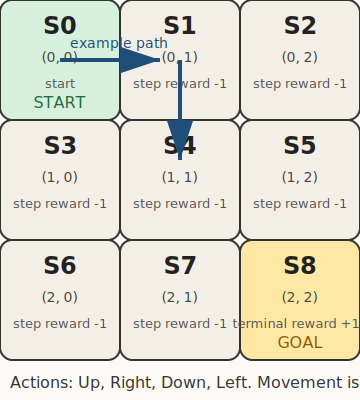

In [17]:
from IPython.display import SVG, display

config = GridWorldConfig()
cell_size = 120
rows, cols = config.rows, config.cols
width = cols * cell_size
height = rows * cell_size

cells = []
for state in range(rows * cols):
    row, col = divmod(state, cols)
    x = col * cell_size
    y = row * cell_size

    fill = '#f4efe6'
    label = f'S{state}'
    subtitle = 'step reward -1'
    accent = ''

    if state == config.start_state:
        fill = '#d7f0dd'
        subtitle = 'start'
        accent = '<text x="{x_mid}" y="{y_acc}" text-anchor="middle" font-size="16" fill="#206a3a">START</text>'
    if state == config.goal_state:
        fill = '#ffe8a3'
        subtitle = 'terminal reward +10'
        accent = '<text x="{x_mid}" y="{y_acc}" text-anchor="middle" font-size="16" fill="#8a5a00">GOAL</text>'

    cells.append(f'''
    <rect x="{x}" y="{y}" width="{cell_size}" height="{cell_size}" fill="{fill}" stroke="#333" stroke-width="2" rx="12" />
    <text x="{x + cell_size/2}" y="{y + 34}" text-anchor="middle" font-size="24" font-weight="bold" fill="#222">{label}</text>
    <text x="{x + cell_size/2}" y="{y + 62}" text-anchor="middle" font-size="14" fill="#444">({row}, {col})</text>
    <text x="{x + cell_size/2}" y="{y + 88}" text-anchor="middle" font-size="13" fill="#555">{subtitle}</text>
    {accent.format(x_mid=x + cell_size/2, y_acc=y + 108) if accent else ''}
    ''')

arrow_overlay = '''
<defs>
  <marker id="arrow" markerWidth="10" markerHeight="10" refX="9" refY="3" orient="auto" markerUnits="strokeWidth">
    <path d="M0,0 L0,6 L9,3 z" fill="#1f4e79" />
  </marker>
</defs>
<line x1="60" y1="60" x2="160" y2="60" stroke="#1f4e79" stroke-width="4" marker-end="url(#arrow)" />
<line x1="180" y1="60" x2="180" y2="160" stroke="#1f4e79" stroke-width="4" marker-end="url(#arrow)" />
<text x="70" y="48" font-size="14" fill="#1f4e79">example path</text>
'''

svg = f'''
<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height + 40}" viewBox="0 0 {width} {height + 40}">
  <rect width="100%" height="100%" fill="#fcfaf6" />
  {''.join(cells)}
  {arrow_overlay}
  <text x="10" y="{height + 28}" font-size="16" fill="#333">Actions: Up, Right, Down, Left. Movement is stochastic: 0.8 intended, 0.1 slip-left, 0.1 slip-right.</text>
</svg>
'''

display(SVG(svg))


## Environment Details

This environment is a small stochastic grid world.

- States are numbered row-by-row from `S0` to `S8`.
- Actions are `Up`, `Right`, `Down`, and `Left`.
- An action does not execute perfectly every time: with probability `0.8` the intended move happens, with probability `0.1` the agent slips to the action on the left, and with probability `0.1` it slips to the action on the right.
- If a move would leave the grid, the agent stays within the boundary.
- The goal state is terminal and loops to itself with reward `0` on later transitions.


In [18]:
env = GridWorldCaseStudyEnv()
config = env.config

print('Environment summary')
print(f'- grid size: {config.rows} x {config.cols}')
print(f'- states: {env.observation_space.n}')
print(f'- actions: {env.action_space.n} -> {ACTION_NAMES}')
print(f'- start state: {config.start_state}')
print(f'- goal state: {config.goal_state}')
print(f'- step reward: {config.step_reward}')
print(f'- goal reward: {config.goal_reward}')
print(f'- transition probabilities: intended={config.intended_move_prob}, slip-left={config.slip_left_prob}, slip-right={config.slip_right_prob}')

print('\nState index layout')
for row in range(config.rows):
    row_states = [row * config.cols + col for col in range(config.cols)]
    print(row_states)

print('\nExample transition distributions from the start state S0')
for action in [UP, RIGHT, DOWN, LEFT]:
    print(f'\nAction {ACTION_NAMES[action]}')
    for prob, next_state, reward, done in env.P[config.start_state][action]:
        print(f'  p={prob:.1f} -> S{next_state}, reward={reward}, done={done}')

print('\nTerminal-state behavior at the goal S8')
for prob, next_state, reward, done in env.P[config.goal_state][RIGHT]:
    print(f'  p={prob:.1f} -> S{next_state}, reward={reward}, done={done}')


Environment summary
- grid size: 3 x 3
- states: 9
- actions: 4 -> {0: 'Up', 1: 'Right', 2: 'Down', 3: 'Left'}
- start state: 0
- goal state: 8
- step reward: -1.0
- goal reward: 10.0
- transition probabilities: intended=0.8, slip-left=0.1, slip-right=0.1

State index layout
[0, 1, 2]
[3, 4, 5]
[6, 7, 8]

Example transition distributions from the start state S0

Action Up
  p=0.9 -> S0, reward=-1.0, done=False
  p=0.1 -> S1, reward=-1.0, done=False

Action Right
  p=0.8 -> S1, reward=-1.0, done=False
  p=0.1 -> S0, reward=-1.0, done=False
  p=0.1 -> S3, reward=-1.0, done=False

Action Down
  p=0.8 -> S3, reward=-1.0, done=False
  p=0.1 -> S1, reward=-1.0, done=False
  p=0.1 -> S0, reward=-1.0, done=False

Action Left
  p=0.9 -> S0, reward=-1.0, done=False
  p=0.1 -> S3, reward=-1.0, done=False

Terminal-state behavior at the goal S8
  p=1.0 -> S8, reward=0.0, done=True


![Policies](./pi_p_depiction.svg)

## Reset Check

A quick sanity check: resetting the environment should place the agent back in the configured start state and return an empty info dictionary.


In [19]:
env = GridWorldCaseStudyEnv()
state, info = env.reset()
state, info


(0, {})